# Credit Card Fraud Detection
- Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Models:
    1. Logistic Regression
    2. XG Boost
    3. Decision Tree
    4. Random Forest
    5. KNN
    6. Naive Bayes

## Problem Definition
Goal: build a model that reliably catches fraudulent transactions despite them being extremely rare.

In [31]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, fbeta_score
from imblearn.over_sampling import SMOTE

## Data Collection

In [4]:
#Load Dataset
df = pd.read_csv('creditcard.csv')

In [74]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Classes
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,Not Fraud
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,Not Fraud
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,Not Fraud
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,Not Fraud
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,Not Fraud


In [5]:
df.shape

(284807, 31)

In [8]:
print("\nClass distribution:")
print(df['Class'].value_counts())  #Check class balance

#Check for nulls
print("Total missing values:", df.isnull().sum().sum())

#Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

df['Class'].value_counts(normalize=True) * 100


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Total missing values: 0

Duplicate rows: 1081


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

There is Class Imbalance
- 0 - Not Fraud
- 1 - Fraud

In [9]:
#seperating for data analysis
notFraud = df[df.Class == 0]
fraud = df[df.Class == 1]

In [10]:
notFraud.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [11]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

## Preprocessing

In [13]:
#Drop duplicates
df = df.drop_duplicates()
#not dropping duplicates cause we are losing some fraud cases

print("New shape:", df.shape)
print("\nClass distribution after dropping duplicates:")
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

New shape: (283726, 31)

Class distribution after dropping duplicates:
Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


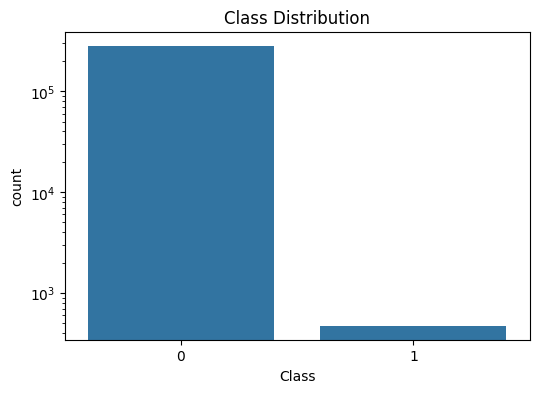

In [15]:
#Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Class')
plt.title('Class Distribution')
plt.yscale('log')  #log scale needed- fraud bar would be invisible otherwise
plt.show()

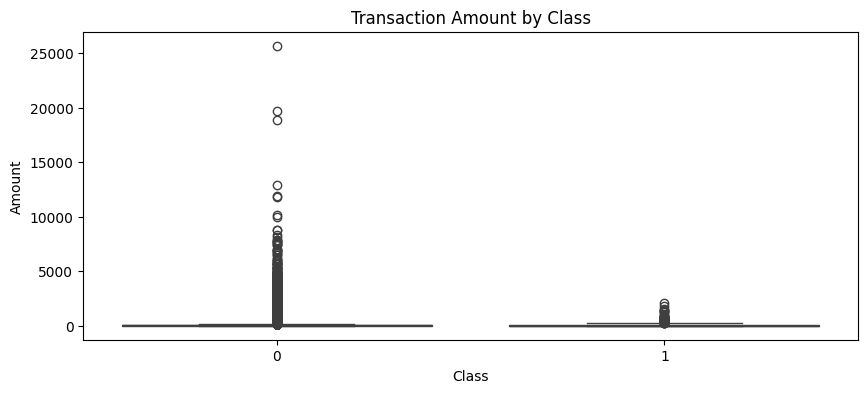

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [18]:
#Amount distribution: fraud vs not fraud
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='Class', y='Amount')
plt.title('Transaction Amount by Class')
plt.show()

print(df.groupby('Class')['Amount'].describe())

### Split Test-Train Data

In [21]:
fraud_percentage = (
    df["Class"].value_counts(normalize=True) * 100
)

fraud_percentage

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [22]:
X = df.drop("Class", axis=1)

y = df["Class"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape :", y.shape)

Feature Matrix Shape : (283726, 30)
Target Vector Shape : (283726,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (226980, 30)
Testing Set : (56746, 30)


In [24]:
# 1. Check X_train for any columns that are 'object' (text) types
print(X_train.dtypes[X_train.dtypes == 'object'])

# 2. Check what is inside y_train
print(y_train.head())

Series([], dtype: object)
226238    0
134253    0
186465    0
149493    0
18461     0
Name: Class, dtype: int64


In [26]:
#Random Sampling
train_df = pd.concat([X_train, y_train], axis=1)

notFraud = train_df[train_df.Class == 0]
fraud = train_df[train_df.Class == 1]

# 2. Randomly sample the non-fraud cases to match the exact number of fraud cases
notFraud_undersampled = notFraud.sample(n=len(fraud), random_state=42)

# 3. Combine the fraud cases with the newly undersampled non-fraud cases
balanced_df = pd.concat([fraud, notFraud_undersampled])

# 4. Shuffle the data so the fraud and non-fraud rows are randomly mixed up
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Split them back apart into our newly balanced X_train and y_train!
X_train_balanced = balanced_df.drop(columns=['Class'])
y_train_balanced = balanced_df['Class']

# Quick check to prove it worked
print("New Class Split:\n", y_train_balanced.value_counts())

# (Note: I fixed a tiny typo in your print statement below where it said y_train instead of X_test!)
print("\nTrain shape:", X_train_balanced.shape, "Test shape:", X_test.shape)
print("Train fraud ratio:\n", y_train_balanced.value_counts(normalize=True))
print("Test fraud ratio:\n", y_test.value_counts(normalize=True))

New Class Split:
 Class
0    378
1    378
Name: count, dtype: int64

Train shape: (756, 30) Test shape: (56746, 30)
Train fraud ratio:
 Class
0    0.5
1    0.5
Name: proportion, dtype: float64
Test fraud ratio:
 Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


### Feature Scaling

In [27]:
numeric_features = ["Time", "Amount"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            RobustScaler(),
            numeric_features
        )
    ],
    remainder="passthrough"
)

In [28]:
print(X_train.columns.tolist())

X_train

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
226238,144549.0,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,...,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,32.00
134253,80716.0,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,...,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,6.99
186465,127116.0,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,...,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,14.95
149493,91342.0,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,...,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,17.30
18461,29522.0,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,...,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,24.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225116,144113.0,-0.098309,-0.382823,0.202726,-0.732301,0.336342,-0.253872,0.837947,-0.402611,-1.424484,...,0.028820,0.154790,1.009327,0.002124,-0.462865,-0.422526,0.010597,0.041090,-0.004501,124.00
3525,3013.0,-1.708940,-1.296255,1.953170,-2.277028,-0.510388,0.408807,0.329231,0.477331,1.058119,...,0.557379,0.466843,0.860939,0.361317,-0.264732,0.423478,0.065689,-0.026392,0.077562,261.80
242674,151594.0,-0.875424,1.159992,0.573970,1.178888,-0.206267,0.260623,0.371124,0.443532,-0.011588,...,-0.353885,-0.100597,-0.157726,0.049751,-0.014156,-0.513855,-0.771982,-0.242970,0.094879,37.00
60594,49395.0,1.247036,0.348595,0.589407,0.982998,-0.222000,-0.452687,-0.012336,-0.140168,0.052173,...,-0.042753,-0.211495,-0.556038,0.037106,-0.133330,0.403622,-0.595756,0.043911,0.032002,5.00


## Model Training

### Logistic Regression

Using Class weight parameter: https://www.geeksforgeeks.org/machine-learning/how-does-the-classweight-parameter-in-scikit-learn-work/

Accuracy: 0.9985955549313578

Classification Report:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.56      0.82      0.67       148

    accuracy                           1.00     85443
   macro avg       0.78      0.91      0.83     85443
weighted avg       1.00      1.00      1.00     85443



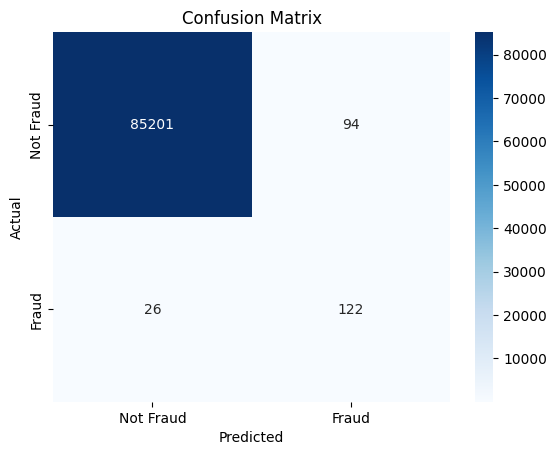

In [49]:
class_weight = {0: 1, 1: 30}  # much gentler than the ~300x 'balanced' would calculate
model = LogisticRegression(solver='lbfgs', max_iter=200, class_weight=class_weight)
model.fit(X_train, y_train)

y_pred_cw2 = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_cw2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cw2, target_names=['Not Fraud', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_cw2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### SMOTE (training data only)
reference: https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64

Class
0    50.0
1    50.0
Name: proportion, dtype: float64


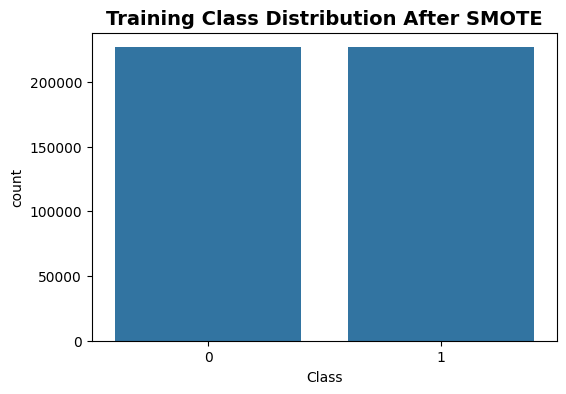

In [29]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE")

print(y_train_sm.value_counts())

print()

print(
    y_train_sm.value_counts(normalize=True) * 100
)

plt.figure(figsize=(6,4))

sns.countplot(
    x=y_train_sm
)

plt.title(
    "Training Class Distribution After SMOTE",
    fontsize=14,
    fontweight="bold"
)

plt.show()

### XG Boost
- References: https://www.geeksforgeeks.org/machine-learning/xgboost/

XG Boost on Test
Model Accuracy: 0.9994382219725431

Classification Report
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.95      0.71      0.81       148

    accuracy                           1.00     85443
   macro avg       0.98      0.85      0.91     85443
weighted avg       1.00      1.00      1.00     85443

F2-score (Fraud): 0.7479
XG Boost on Train
Model Accuracy: 0.999533516582733

Classification Report
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    199020
       Fraud       0.95      0.77      0.85       344

    accuracy                           1.00    199364
   macro avg       0.97      0.89      0.93    199364
weighted avg       1.00      1.00      1.00    199364



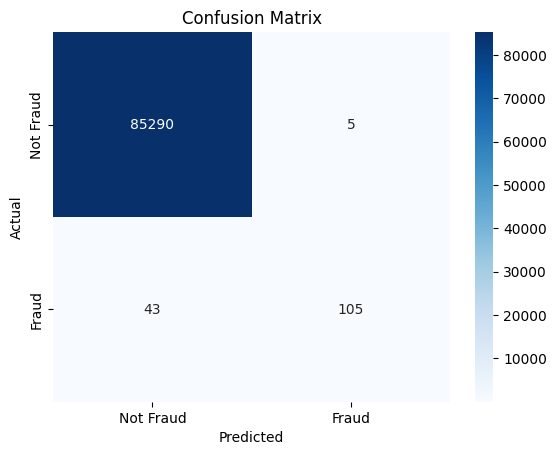

In [55]:
params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}

model = XGBClassifier(**params)
model.fit(X_train, y_train)

#on test
print('XG Boost on Test')
y_pred_xg_test = model.predict(X_test)

accuracy_xg_test = accuracy_score(y_test, y_pred_xg_test)
print("Model Accuracy:", accuracy_xg_test)

print("\nClassification Report")
print(classification_report(y_test, y_pred_xg_test, target_names=['Not Fraud', 'Fraud']))

f2 = fbeta_score(y_test, y_pred_xg_test, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2:.4f}")

#on train
print('XG Boost on Train')
y_pred_xg_train = model.predict(X_train)

accuracy_xg_train = accuracy_score(y_train, y_pred_xg_train)
print("Model Accuracy:", accuracy_xg_train)

print("\nClassification Report")
print(classification_report(y_train, y_pred_xg_train, target_names=['Not Fraud', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_xg_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
param_dist = {
    'max_depth': randint(3, 6),
    'learning_rate': uniform(0.01, 0.19),   # samples between 0.01 and 0.3
    'n_estimators': randint(100, 250),
    'alpha': uniform(0, 15),                 # L1 regularization
    'subsample': uniform(0.6, 0.3),          # samples between 0.6 and 1.0
    'colsample_bytree': uniform(0.6, 0.3),
}

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,   # keep your imbalance handling built in
    eval_metric='logloss',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,             # number of random combinations to try — keep this modest for speed
    scoring='f1',          # optimize for F1, matching how you've judged every other model
    cv=3,                  # 3-fold, not 5 — faster, still reasonably robust
    n_jobs=-1,              # use all CPU cores
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best F1 (cross-validated):", random_search.best_score_)


random_search2 = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search2.fit(X_train, y_train)
print("Best parameters:", random_search2.best_params_)

best_xgb2 = random_search2.best_estimator_
y_pred_best_xgb2 = best_xgb2.predict(X_test)
y_train_pred_best2 = best_xgb2.predict(X_train)

print("\nTest:")
print(classification_report(y_test, y_pred_best_xgb2, target_names=['Not Fraud', 'Fraud'], zero_division=0))
print("\nTrain:")
print(classification_report(y_train, y_train_pred_best2, target_names=['Not Fraud', 'Fraud'], zero_division=0))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'alpha': np.float64(2.3399178050430396), 'colsample_bytree': np.float64(0.6174250836504598), 'learning_rate': np.float64(0.1745734676972377), 'max_depth': 5, 'n_estimators': 249, 'subsample': np.float64(0.61692347370813)}
Best F1 (cross-validated): 0.8496082576650262
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'alpha': np.float64(2.3399178050430396), 'colsample_bytree': np.float64(0.6174250836504598), 'learning_rate': np.float64(0.1745734676972377), 'max_depth': 5, 'n_estimators': 249, 'subsample': np.float64(0.61692347370813)}

Test:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.88      0.79      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443


Train:
          

In [24]:
best_xgb = random_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred_best_xgb, target_names=['Not Fraud', 'Fraud'], zero_division=0))

f2 = fbeta_score(y_test, y_pred_best_xgb, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2:.4f}")

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.88      0.79      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443

F2-score (Fraud): 0.8069


check if overfitting

In [25]:
y_train_pred_best = best_xgb.predict(X_train)
print("XGBoost (tuned) — Train Results:")
print(classification_report(y_train, y_train_pred_best, target_names=['Not Fraud', 'Fraud'], zero_division=0))

XGBoost (tuned) — Train Results:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    199020
       Fraud       0.99      1.00      1.00       344

    accuracy                           1.00    199364
   macro avg       1.00      1.00      1.00    199364
weighted avg       1.00      1.00      1.00    199364



### Random Forest
- https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/
- https://www.geeksforgeeks.org/maths/random-sampling/

[0.09754448 0.16920976 0.57338454 0.0124902  0.81767776 0.05706095
 0.07173242 0.03022323 0.06765028 0.00805812]
Random Forest on test on Random Sampling:
Accuracy: 0.9725

              precision    recall  f1-score   support

   Not Fraud       1.00      0.97      0.99     56864
       Fraud       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.54     56962
weighted avg       1.00      0.97      0.98     56962

F2-score (Fraud): 0.2204


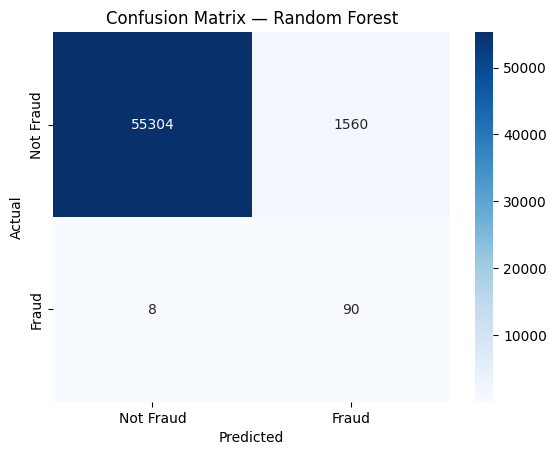

[0.09754448 0.16920976 0.57338454 0.0124902  0.81767776 0.05706095
 0.07173242 0.03022323 0.06765028 0.00805812]
Random Forest on on SMOTE:
Accuracy: 0.9983

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.50      0.89      0.64        98

    accuracy                           1.00     56962
   macro avg       0.75      0.94      0.82     56962
weighted avg       1.00      1.00      1.00     56962

F2-score (Fraud): 0.7672


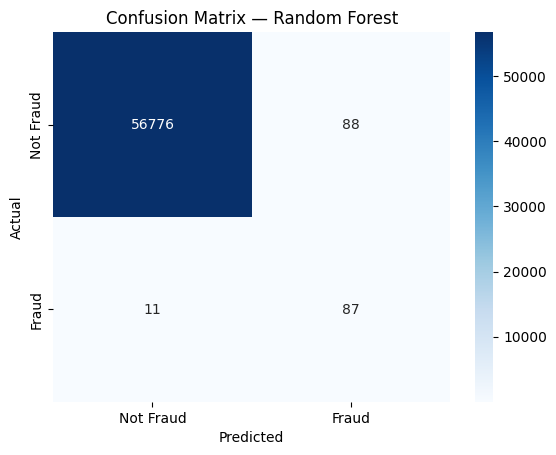

In [ ]:
RF_classifier_random = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
RF_classifier_random.fit(X_train_balanced, y_train_balanced)

y_pred_rf_r = RF_classifier_random.predict(X_test)
y_probs_rf_r = RF_classifier_random.predict_proba(X_test)[:, 1]  #probability of Fraud (class 1)

print(y_probs_rf_r[:10])  #quick look at the first 10 probability scores

#to fix the overfitting.
#max_depth=10 - stop after 10 questions, to avoid Memorization/reduce noise
#min_samples_leaf=5 - every leaf must contain at least 5 training samples.

print("Random Forest on test on Random Sampling:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_r):.4f}\n")
print(classification_report(y_test, y_pred_rf_r, target_names=['Not Fraud', 'Fraud'], zero_division=0))

f2 = fbeta_score(y_test, y_pred_rf_r, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2:.4f}")

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf_r)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Random Forest')
plt.show()

[0.    0.    0.005 0.    0.    0.    0.    0.    0.    0.   ]
Random Forest on on SMOTE:
Accuracy: 0.9995

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

F2-score (Fraud): 0.7935


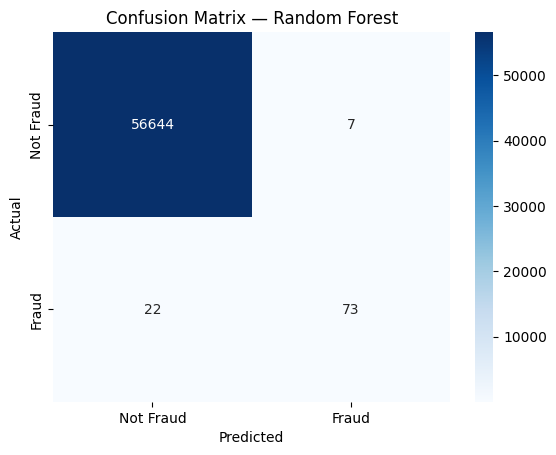

In [33]:
#SMOTE
#X_train_sm, y_train_sm
rf_pipeline_smote = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ))])
    
rf_pipeline_smote.fit(X_train_sm, y_train_sm)

y_pred_rf_smote = rf_pipeline_smote.predict(X_test)
y_probs_rf_smote = rf_pipeline_smote.predict_proba(X_test)[:, 1]  #probability of Fraud (class 1)

print(y_probs_rf_smote[:10])  #quick look at the first 10 probability scores

print("Random Forest SMOTE:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_smote):.4f}\n")
print(classification_report(y_test, y_pred_rf_smote, target_names=['Not Fraud', 'Fraud'], zero_division=0))

f2 = fbeta_score(y_test, y_pred_rf_smote, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2:.4f}")

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf_smote)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Random Forest')
plt.show() 

Random Forest on test:
Accuracy: 0.9995

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.97      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

F2-score (Fraud): 0.7556
Random Forest on train data:
Accuracy: 0.9997

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    226602
       Fraud       0.97      0.83      0.89       378

    accuracy                           1.00    226980
   macro avg       0.99      0.91      0.95    226980
weighted avg       1.00      1.00      1.00    226980



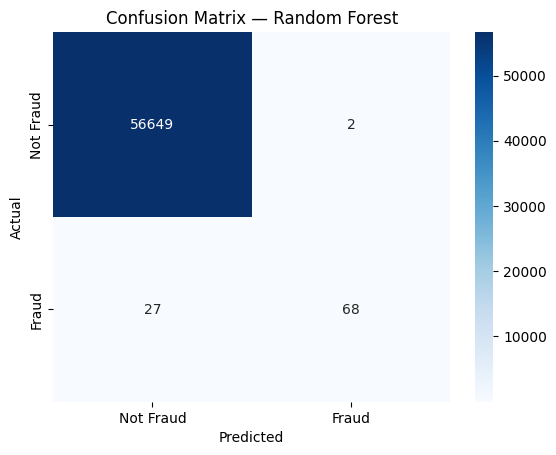

In [34]:
RF_classifier = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
RF_classifier.fit(X_train, y_train)

y_pred_rf = RF_classifier.predict(X_test)
y_probs_rf = RF_classifier.predict_proba(X_test)[:, 1]  #probability of Fraud (class 1)

#on test
print("Random Forest on test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=['Not Fraud', 'Fraud'], zero_division=0))

f2 = fbeta_score(y_test, y_pred_rf, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2:.4f}")

#on train
y_pred_rf_train = RF_classifier.predict(X_train)
print("Random Forest on train data:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}\n")
print(classification_report(y_train, y_pred_rf_train, target_names=['Not Fraud', 'Fraud'], zero_division=0))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Random Forest')
plt.show()

### Feature Importance

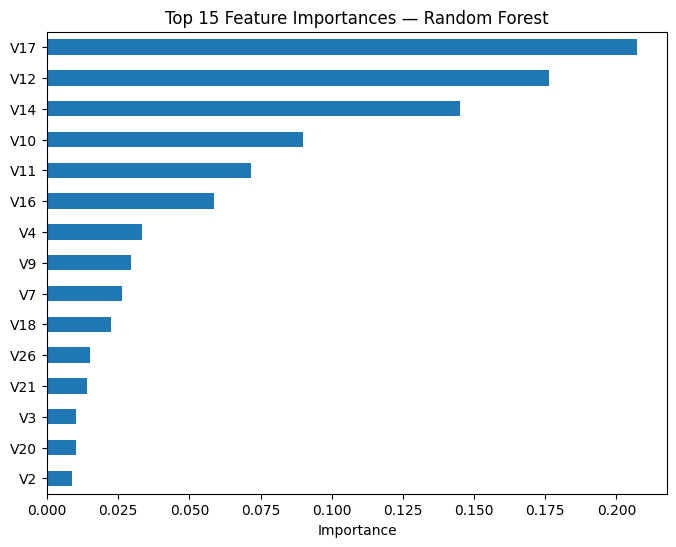

In [62]:
importances = pd.Series(RF_classifier.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.show()

### SHAP

Overall Feature Importance (Summary Plot)


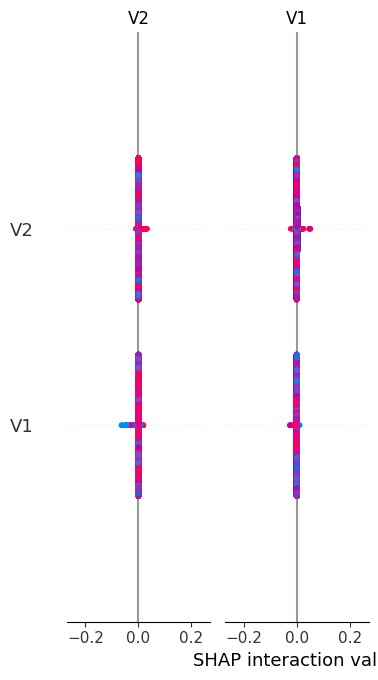

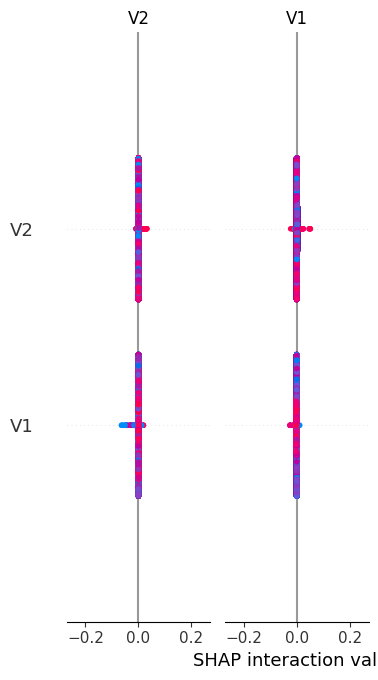


Explaining Transaction #0 (For the Fraud Class)


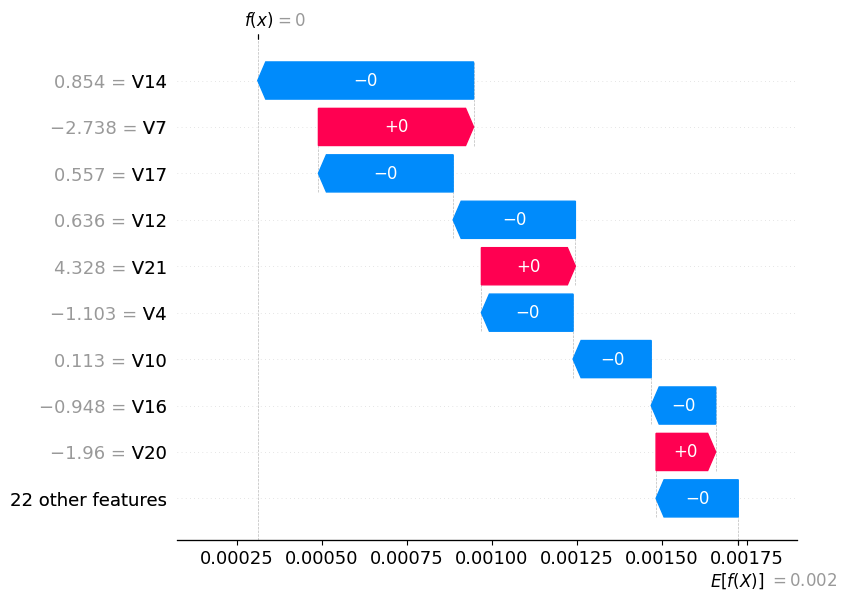

In [65]:
explainer = shap.TreeExplainer(RF_classifier)
shap_values = explainer.shap_values(X_test)

print("Overall Feature Importance (Summary Plot)")
shap.summary_plot(shap_values, X_test)

# 5. LOCAL EXPLANATION: The Waterfall Plot (Explaining a SINGLE transaction)
print("\nExplaining Transaction #0 (For the Fraud Class)")

# Calculate the explanation object
shap_obj = explainer(X_test)

# Slice it to grab Row 0, All Features (:), and Class 1 (Fraud)
shap.plots.waterfall(shap_obj[0, :, 1])

### Threshold Tuning
- References: https://youtu.be/2dwdNRxzksE?si=gN95KYbzEOSzaN7f

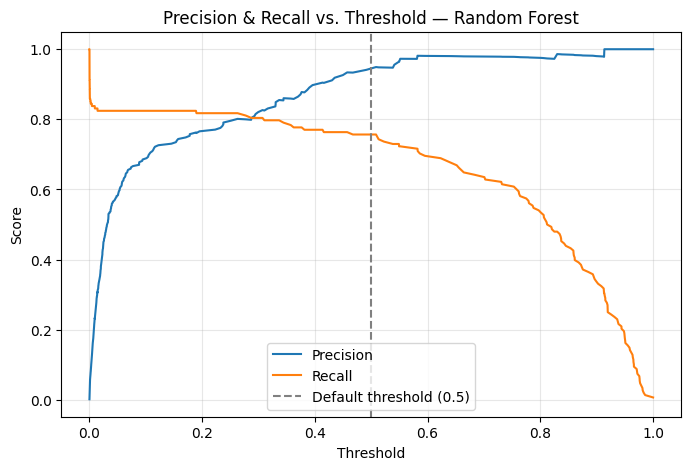

In [19]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_rf)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs. Threshold — Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [35]:
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.65, 0.7]:
    y_pred_t = (y_probs_rf >= t).astype(int)
    print(f"Threshold = {t}")
    print(classification_report(y_test, y_pred_t, target_names=['Not Fraud', 'Fraud'], zero_division=0))
    print("-"*50)

Threshold = 0.2
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.85      0.77      0.81        95

    accuracy                           1.00     56746
   macro avg       0.92      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------
Threshold = 0.3
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.88      0.77      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------
Threshold = 0.4
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.92      0.76      0.83        95

    accuracy                    

F2-score (Fraud): 0.7833
Random Forest — Final Threshold = 0.2
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.85      0.77      0.81        95

    accuracy                           1.00     56746
   macro avg       0.92      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746



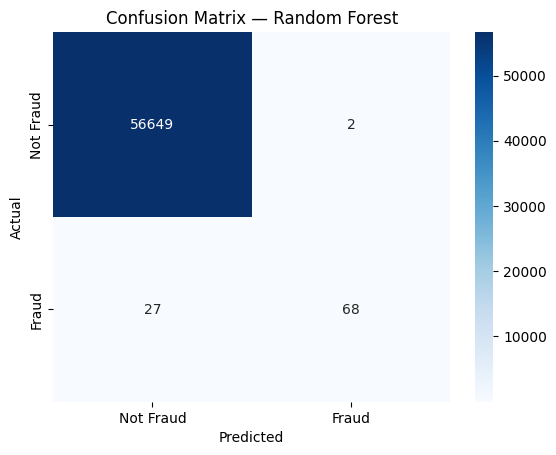

In [36]:
final_threshold = 0.2
y_pred_final = (y_probs_rf >= final_threshold).astype(int)

f2 = fbeta_score(y_test, y_pred_final, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2:.4f}")

print(f"Random Forest — Final Threshold = {final_threshold}")
print(classification_report(y_test, y_pred_final, target_names=['Not Fraud', 'Fraud'], zero_division=0))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Random Forest')
plt.show()

In [22]:
# Get probability scores on the training set
y_probs_rf_train = RF_classifier.predict_proba(X_train)[:, 1]

# Apply the same threshold = 0.2 used for your final model
y_pred_rf_train_tuned = (y_probs_rf_train >= 0.2).astype(int)

print("Random Forest @ threshold=0.2 — Train Results:")
print(classification_report(y_train, y_pred_rf_train_tuned, target_names=['Not Fraud', 'Fraud'], zero_division=0))

f2_train = fbeta_score(y_train, y_pred_rf_train_tuned, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud, Train): {f2_train:.4f}")

Random Forest @ threshold=0.2 — Train Results:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    199020
       Fraud       0.86      0.85      0.86       344

    accuracy                           1.00    199364
   macro avg       0.93      0.93      0.93    199364
weighted avg       1.00      1.00      1.00    199364

F2-score (Fraud, Train): 0.8542


### Decision Tree

Decision Tree on Train:
Accuracy: 0.9998

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    199020
       Fraud       0.99      0.92      0.95       344

    accuracy                           1.00    199364
   macro avg       0.99      0.96      0.98    199364
weighted avg       1.00      1.00      1.00    199364


Decision Tree on Test:
Accuracy: 0.9993

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.86      0.71      0.78       148

    accuracy                           1.00     85443
   macro avg       0.93      0.85      0.89     85443
weighted avg       1.00      1.00      1.00     85443



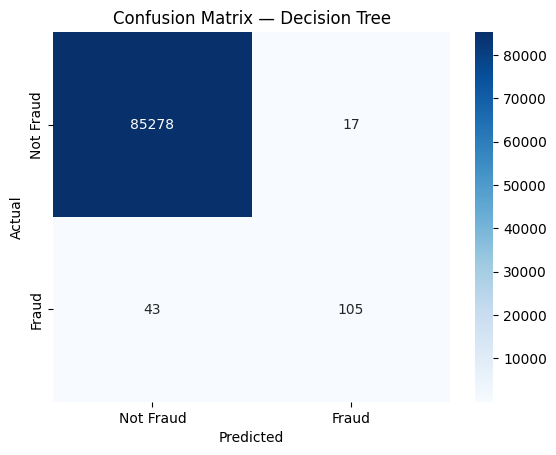

In [31]:
tree_params = None

if tree_params is None:
    tree_params = {
        'criterion': 'gini',
        'max_depth': 10,
        'random_state': 42
    }

model_dt = DecisionTreeClassifier(class_weight={0: 1, 1: 10}, **tree_params)

#Training
model_dt.fit(X_train, y_train)

#Predict + evaluate
y_train_pred = model_dt.predict(X_train)
print("Decision Tree on Train:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}\n")
print(classification_report(y_train, y_train_pred, target_names=['Not Fraud', 'Fraud'], zero_division=0))

y_preds_dt = model_dt.predict(X_test)
print("\nDecision Tree on Test:")
print(f"Accuracy: {accuracy_score(y_test, y_preds_dt):.4f}\n")
print(classification_report(y_test, y_preds_dt, target_names=['Not Fraud', 'Fraud'], zero_division=0))

#Confusion Matrix
cm = confusion_matrix(y_test, y_preds_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Decision Tree')
plt.show()

###  Find and study the False Negatives

In [32]:
#final predictions (using chosen threshold = 0.2)
y_probs_rf = RF_classifier.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs_rf >= 0.2).astype(int)

#Build a results dataframe to inspect
results_df = X_test.copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred_final
results_df['Fraud_Probability'] = y_probs_rf

#False Negatives: actual fraud (1), predicted not fraud (0)
false_negatives = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)]

#True Positives: actual fraud, correctly caught — for comparison
true_positives = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 1)]

print(f"False Negatives: {len(false_negatives)}")
print(f"True Positives: {len(true_positives)}")

print("\nFalse Negatives — probability scores (how close were they to being caught?):")
print(false_negatives['Fraud_Probability'].describe())

False Negatives: 27
True Positives: 121

False Negatives — probability scores (how close were they to being caught?):
count    27.000000
mean      0.008441
std       0.036231
min       0.000120
25%       0.000189
50%       0.000408
75%       0.000641
max       0.189026
Name: Fraud_Probability, dtype: float64


In [33]:
feature_cols = [c for c in X_test.columns]

comparison = pd.DataFrame({
    'FN_mean': false_negatives[feature_cols].mean(),
    'TP_mean': true_positives[feature_cols].mean(),
})
comparison['abs_diff'] = (comparison['FN_mean'] - comparison['TP_mean']).abs()
comparison = comparison.sort_values('abs_diff', ascending=False)

print(comparison.head(10))

      FN_mean   TP_mean  abs_diff
V17  0.484000 -8.037483  8.521483
V3  -0.389420 -7.775008  7.385587
V7   0.853824 -6.516529  7.370353
V14 -0.711090 -8.052176  7.341086
V12 -0.495796 -7.019786  6.523989
V10 -0.040133 -6.377525  6.337392
V1  -0.488617 -5.676564  5.187947
V16  0.286507 -4.863385  5.149892
V2  -0.321339  4.130025  4.451364
V11  0.129756  4.325500  4.195744


###  Feed the model more examples like the False Negatives

In [34]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(sampling_strategy=0.1, random_state=42, n_neighbors=5)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)

model_ada = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
model_ada.fit(X_train_ada, y_train_ada)

y_pred_ada = model_ada.predict(X_test)
print(classification_report(y_test, y_pred_ada, target_names=['Not Fraud', 'Fraud'], zero_division=0))

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.65      0.81      0.72       148

    accuracy                           1.00     85443
   macro avg       0.82      0.91      0.86     85443
weighted avg       1.00      1.00      1.00     85443



### KNN

Accuracy: 0.9994

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.91      0.70      0.79       148

    accuracy                           1.00     85443
   macro avg       0.96      0.85      0.90     85443
weighted avg       1.00      1.00      1.00     85443



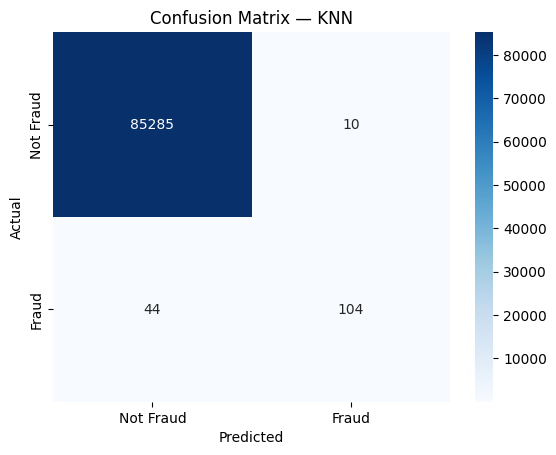

In [35]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)  # n_jobs=-1 uses all CPU cores
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}\n")
print(classification_report(y_test, y_pred_knn, target_names=['Not Fraud', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — KNN')
plt.show()

Accuracy: 0.9781

              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99     85295
       Fraud       0.06      0.80      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.89      0.55     85443
weighted avg       1.00      0.98      0.99     85443



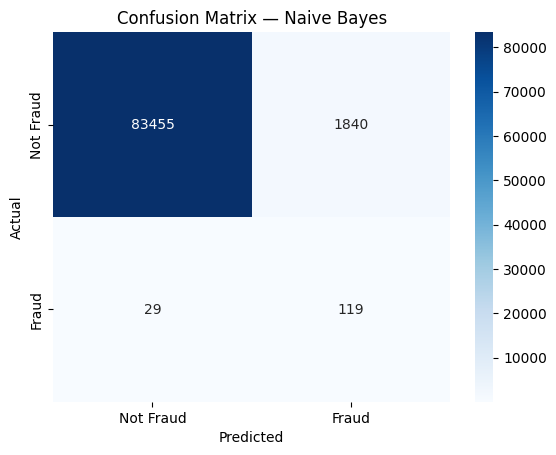

In [36]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")
print(classification_report(y_test, y_pred_nb, target_names=['Not Fraud', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Naive Bayes')
plt.show()

## Model Comparison & Evaluation

| Model | Precision (Fraud) | Recall (Fraud) | F1 (Fraud) | Accuracy |
|---|---|---|---|---|
| Logistic Regression + class weight | 0.56 | 0.82 | 0.67 | 0.9985 |
| Logistic Regression + undersampling | 0.06 | 0.88 | 0.11 | 0.9750 |
| Logistic Regression + SMOTE | 0.06 | 0.86 | 0.11 | 0.9760 |
| XGBoost | 0.95 | 0.71 | 0.81 | 0.9994 |
| Decision Tree | 0.86 | 0.71 | 0.78 | 0.9993 |
| **Random Forest (default threshold)** | **0.95** | **0.76** | **0.84** | **0.9995** |
| KNN | 0.91 | 0.70 | 0.79 | 0.9994 |
| Naive Bayes | 0.06 | 0.80 | 0.11 | 0.9780 |

### Key Findings

*   **Forcing the data to be equal causes too many false alarms.** Methods like Undersampling, SMOTE, and Naive Bayes catch a lot of fraud, but about 94% of their alerts are fake. This would completely waste a fraud team's time.
*   **Simple class weighting:** Just tweaking the "weight" in Logistic Regression worked much better than forcing the data to be balanced. It caught fraud well without blowing up the false alarms.
*   **Tree models:** XGBoost, Decision Tree, Random Forest, and KNN gave the best results naturally, without needing any tricky data adjustments.

**Checking for overfitting (Train vs. Test F1):**

| Model | Test F1 | Train F1 | Gap |
|---|---|---|---|
| XGBoost | 0.81 | 0.85 | 0.04 |
| Decision Tree | 0.78 | 0.95 | 0.17 |
| Random Forest | 0.84 | 0.88 | 0.04 |

Decision Tree shows the largest train-test gap even after tuning (`max_depth=10`, `class_weight={0:1,1:10}`), confirming single trees are more prone to overfitting than ensemble methods. XGBoost and Random Forest both generalize well, with only a small drop from train to test performance.

A hyperparameter search (RandomizedSearchCV) was also run on XGBoost. It reached a slightly higher test F1 (0.83), but showed a perfect train F1 of 1.00 against a test F1 of 0.83 — a much larger overfitting gap than the untuned version. This result was excluded from final model selection for that reason, and is kept here as a reminder that a search optimizing purely for cross-validated score can find settings that memorize the training data rather than generalize.

### Threshold Tuning

Random Forest's default 0.5 threshold was compared against lower thresholds, using F2 (which weights recall twice as heavily as precision) as the deciding metric rather than F1, since missing fraud is costlier than a false alarm in this problem:

| Threshold | Precision | Recall | F1 | F2 |
|---|---|---|---|---|
| 0.2 | 0.77 | 0.82 | 0.79 | 0.81 |
| 0.3 | 0.83 | 0.80 | 0.82 | 0.81 |
| 0.4 | 0.90 | 0.77 | 0.83 | 0.79 |
| 0.5 (default) | 0.95 | 0.76 | 0.84 | 0.79 |
| 0.6 | 0.98 | 0.69 | 0.81 | 0.73 |

Threshold 0.2 gives the highest F2-score (0.81) and was selected as the final decision boundary, improving recall from 0.76 to 0.82 at a moderate precision cost (0.95 to 0.77). Train-set performance at this threshold (F1 0.86, F2 0.85) is close to the test result, confirming this threshold choice does not introduce overfitting.

### Error Analysis: False Negatives

The 27 fraud cases missed by the final model were examined directly. Their predicted fraud probabilities were very low (mean 0.008, median 0.0004), meaning these are not near-miss transactions sitting just under the threshold — the model confidently misclassifies them. Comparing average feature values between missed fraud and correctly caught fraud showed that correctly caught fraud has extreme values in key components (V17, V14, V12, V10), while missed fraud sits close to typical, non-fraud ranges on the same components. This suggests the model reliably catches one distinct pattern of fraud but struggles with a subtler pattern that statistically resembles normal transactions.

ADASYN, which generates synthetic minority-class examples targeting harder-to-classify cases, was tested as a way to address this directly. It did not help: precision dropped from 0.77 to 0.65 with no meaningful recall improvement (0.82 to 0.81). This indicates the missed fraud cases are not simply near a decision boundary that resampling can reinforce — they are camouflaged among normal transactions in the available feature space, and likely require additional features beyond what this anonymized dataset provides to detect reliably.

### Final Model Selection

**Random Forest, evaluated at a tuned threshold of 0.2**, is selected as the final model. Among all non-overfitting models tested, it achieves the best F2-score (0.81), reflecting the project's priority on recall, while maintaining reasonable precision (0.77) and a small, consistent train-test gap.

**XGBoost** (untuned) is the strongest alternative — equally resistant to overfitting, with a similar F2 profile, but slightly lower recall (0.71) than Random Forest at its default threshold.

Aggressive rebalancing techniques (SMOTE, undersampling, Naive Bayes) achieved higher recall but at an impractical precision cost, making them unsuitable for real-world deployment despite their strong recall numbers. The hyperparameter-tuned XGBoost and ADASYN-resampled Random Forest were both tested as potential improvements but were excluded for showing overfitting and reduced precision, respectively.

### Save model for Streamlit

In [23]:
import joblib

#Save the trained Random Forest model
joblib.dump(RF_classifier, 'fraud_model.pkl')

#Save the scaler too, since new input needs the same scaling applied
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved.")

Model and scaler saved.
